In [64]:
import pandas as pd
data=pd.read_csv('data_clean.csv')

In [65]:
data.head(5)

,Unnamed: 0,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,1,41.0,190.0,7.4,67,5,1,2010,67,S
1,2,36.0,118.0,8.0,72,5,2,2010,72,C
2,3,12.0,149.0,12.6,74,5,3,2010,74,PS
3,4,18.0,313.0,11.5,62,5,4,2010,62,S
4,5,NaN,NaN,14.3,56,5,5,2010,56,S


In [66]:
data=data.drop('Unnamed: 0',axis=1)

In [67]:
data.head(2)

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,67,5,1,2010,67,S
1,36.0,118.0,8.0,72,5,2,2010,72,C


In [68]:
data=data.drop('Temp C',axis=1)

In [69]:
data.head(2)

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C


In [70]:
data['Month'].isnull().sum()

np.int64(0)

In [71]:
data['Ozone'].isnull().sum()

np.int64(38)

In [72]:
data['Month']=pd.to_numeric(data['Month'],errors='coerce')

In [73]:
data['Month'].isnull().sum()

np.int64(1)

In [74]:
data['Month']=data['Month'].fillna(5)

In [75]:
data['Month'].isnull().sum()

np.int64(0)

In [76]:
data['Temp']=pd.to_numeric(data['Temp'],errors='coerce')

In [77]:
data['Temp'].isnull().sum()

np.int64(0)

In [78]:
data['Weather']=data['Weather'].astype('category')

In [79]:
data['Weather'].isnull().sum()

np.int64(3)

In [80]:
data.isnull().sum()

Ozone      38
Solar.R     7
Wind        0
Month       0
Day         0
Year        0
Temp        0
Weather     3
dtype: int64

In [81]:
#Duplicated data
data[data.duplicated()].shape

(1, 8)

In [82]:
data[data.duplicated()]

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
156,14.0,191.0,14.3,9.0,28,2010,75,S


In [83]:
data1=data.drop_duplicates()#removing duplicate data

In [84]:
data1[data1.duplicated()].shape

(0, 8)

In [85]:
data1.head(4)

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5.0,1,2010,67,S
1,36.0,118.0,8.0,5.0,2,2010,72,C
2,12.0,149.0,12.6,5.0,3,2010,74,PS
3,18.0,313.0,11.5,5.0,4,2010,62,S


In [86]:
#renaming the file
data2=data1.rename({'Solar.R':'Solar'},axis=1)

In [87]:
data2.head()

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5.0,1,2010,67,S
1,36.0,118.0,8.0,5.0,2,2010,72,C
2,12.0,149.0,12.6,5.0,3,2010,74,PS
3,18.0,313.0,11.5,5.0,4,2010,62,S
4,NaN,NaN,14.3,5.0,5,2010,56,S


In [88]:
data2.isnull().sum()

Ozone      38
Solar       7
Wind        0
Month       0
Day         0
Year        0
Temp        0
Weather     3
dtype: int64

In [89]:
#impuatation

In [90]:
m=data2['Ozone'].mean()

In [91]:
print(m)

41.81512605042017


In [92]:
data2['Ozone']=data2['Ozone'].fillna(m)

In [93]:
#
n=data2['Weather'].mode().iloc[0]

In [94]:
print(n)

S


In [95]:
data2['Weather']=data2['Weather'].fillna(n)

In [96]:
data2.isnull().sum()

Ozone      0
Solar      7
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    0
dtype: int64

In [97]:
o=data2['Solar'].mean()
print(o)

185.36666666666667


In [98]:
data2['Solar']=data2['Solar'].fillna(o)

In [99]:
data2.isnull().sum()

Ozone      0
Solar      0
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    0
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x112faad50>,
 'caps': [<matplotlib.lines.Line2D at 0x112fa9a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x112faae90>],
 'medians': [<matplotlib.lines.Line2D at 0x112fa9e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x112fa9f90>],
 'means': []}

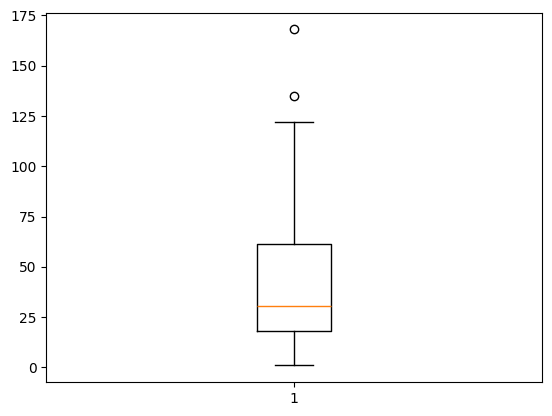

In [100]:
#Box plot
import matplotlib.pyplot as plt
data_box=data1.dropna()
data1_box=data_box.Ozone
plt.boxplot(data1_box)

In [101]:
data_cleaned3=data2

## Scatter plot #not in syllabi

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


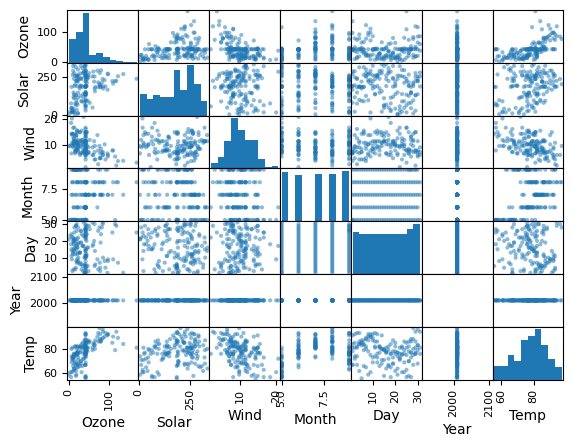

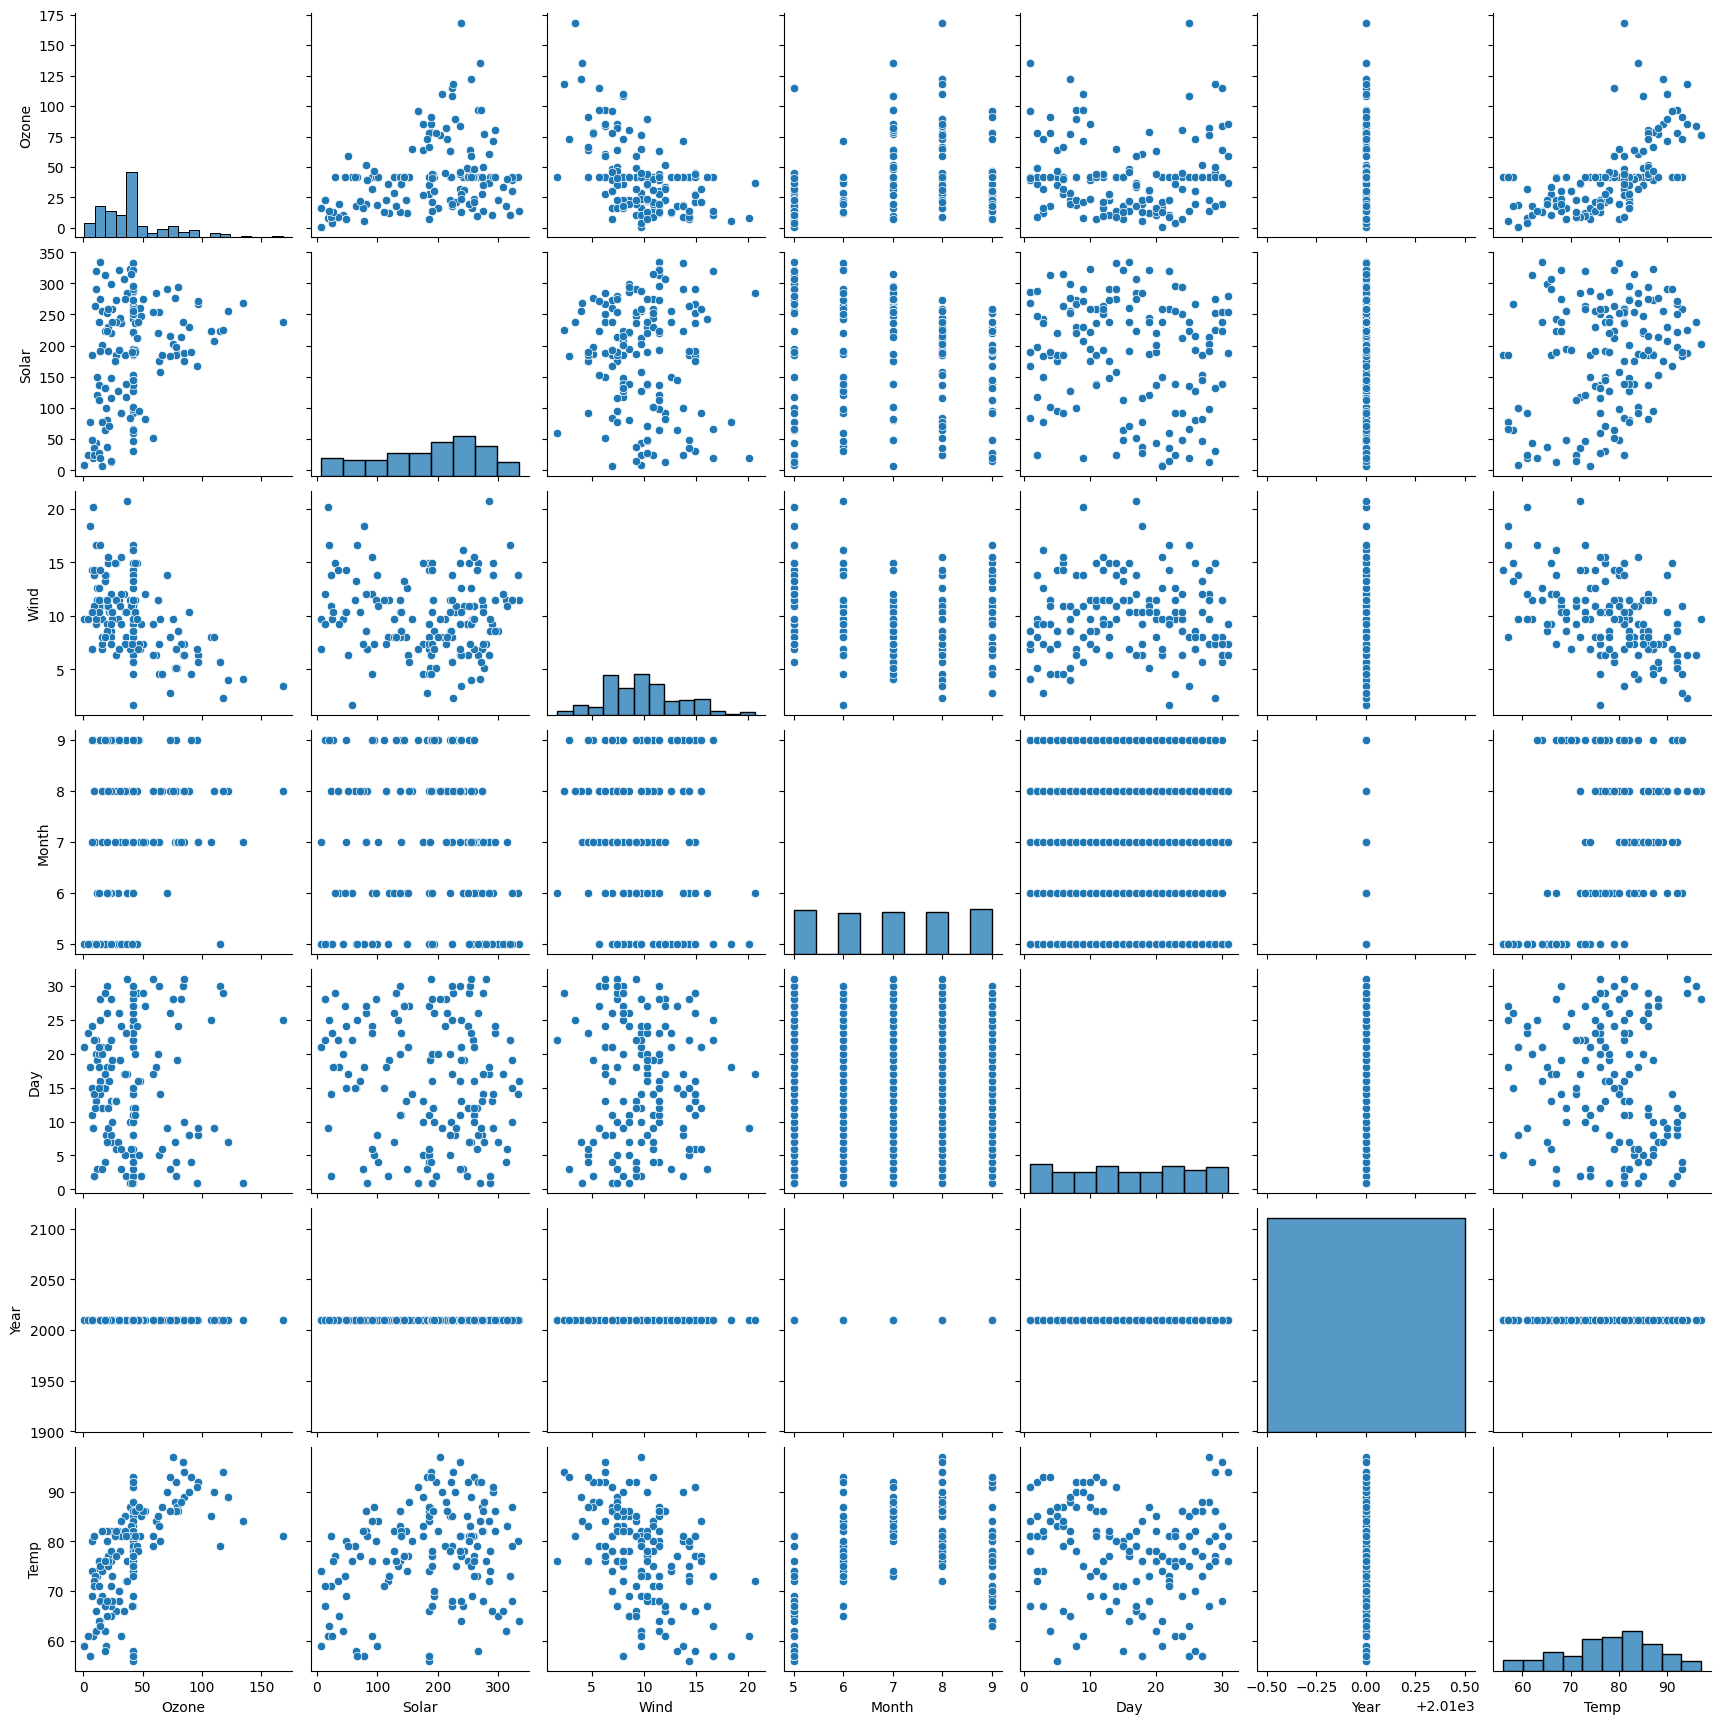

In [102]:
import seaborn as sns
pd.plotting.scatter_matrix(data_cleaned3)
sns.pairplot(data_cleaned3)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


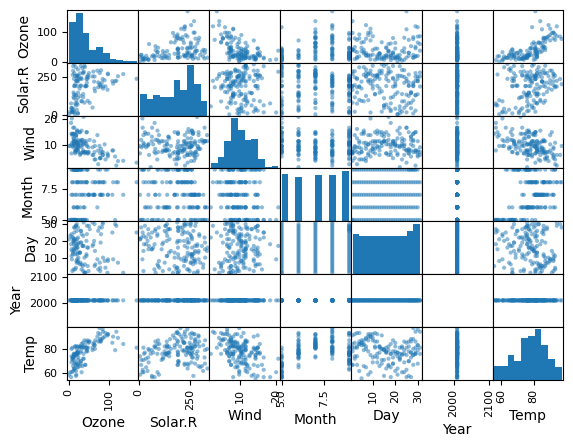

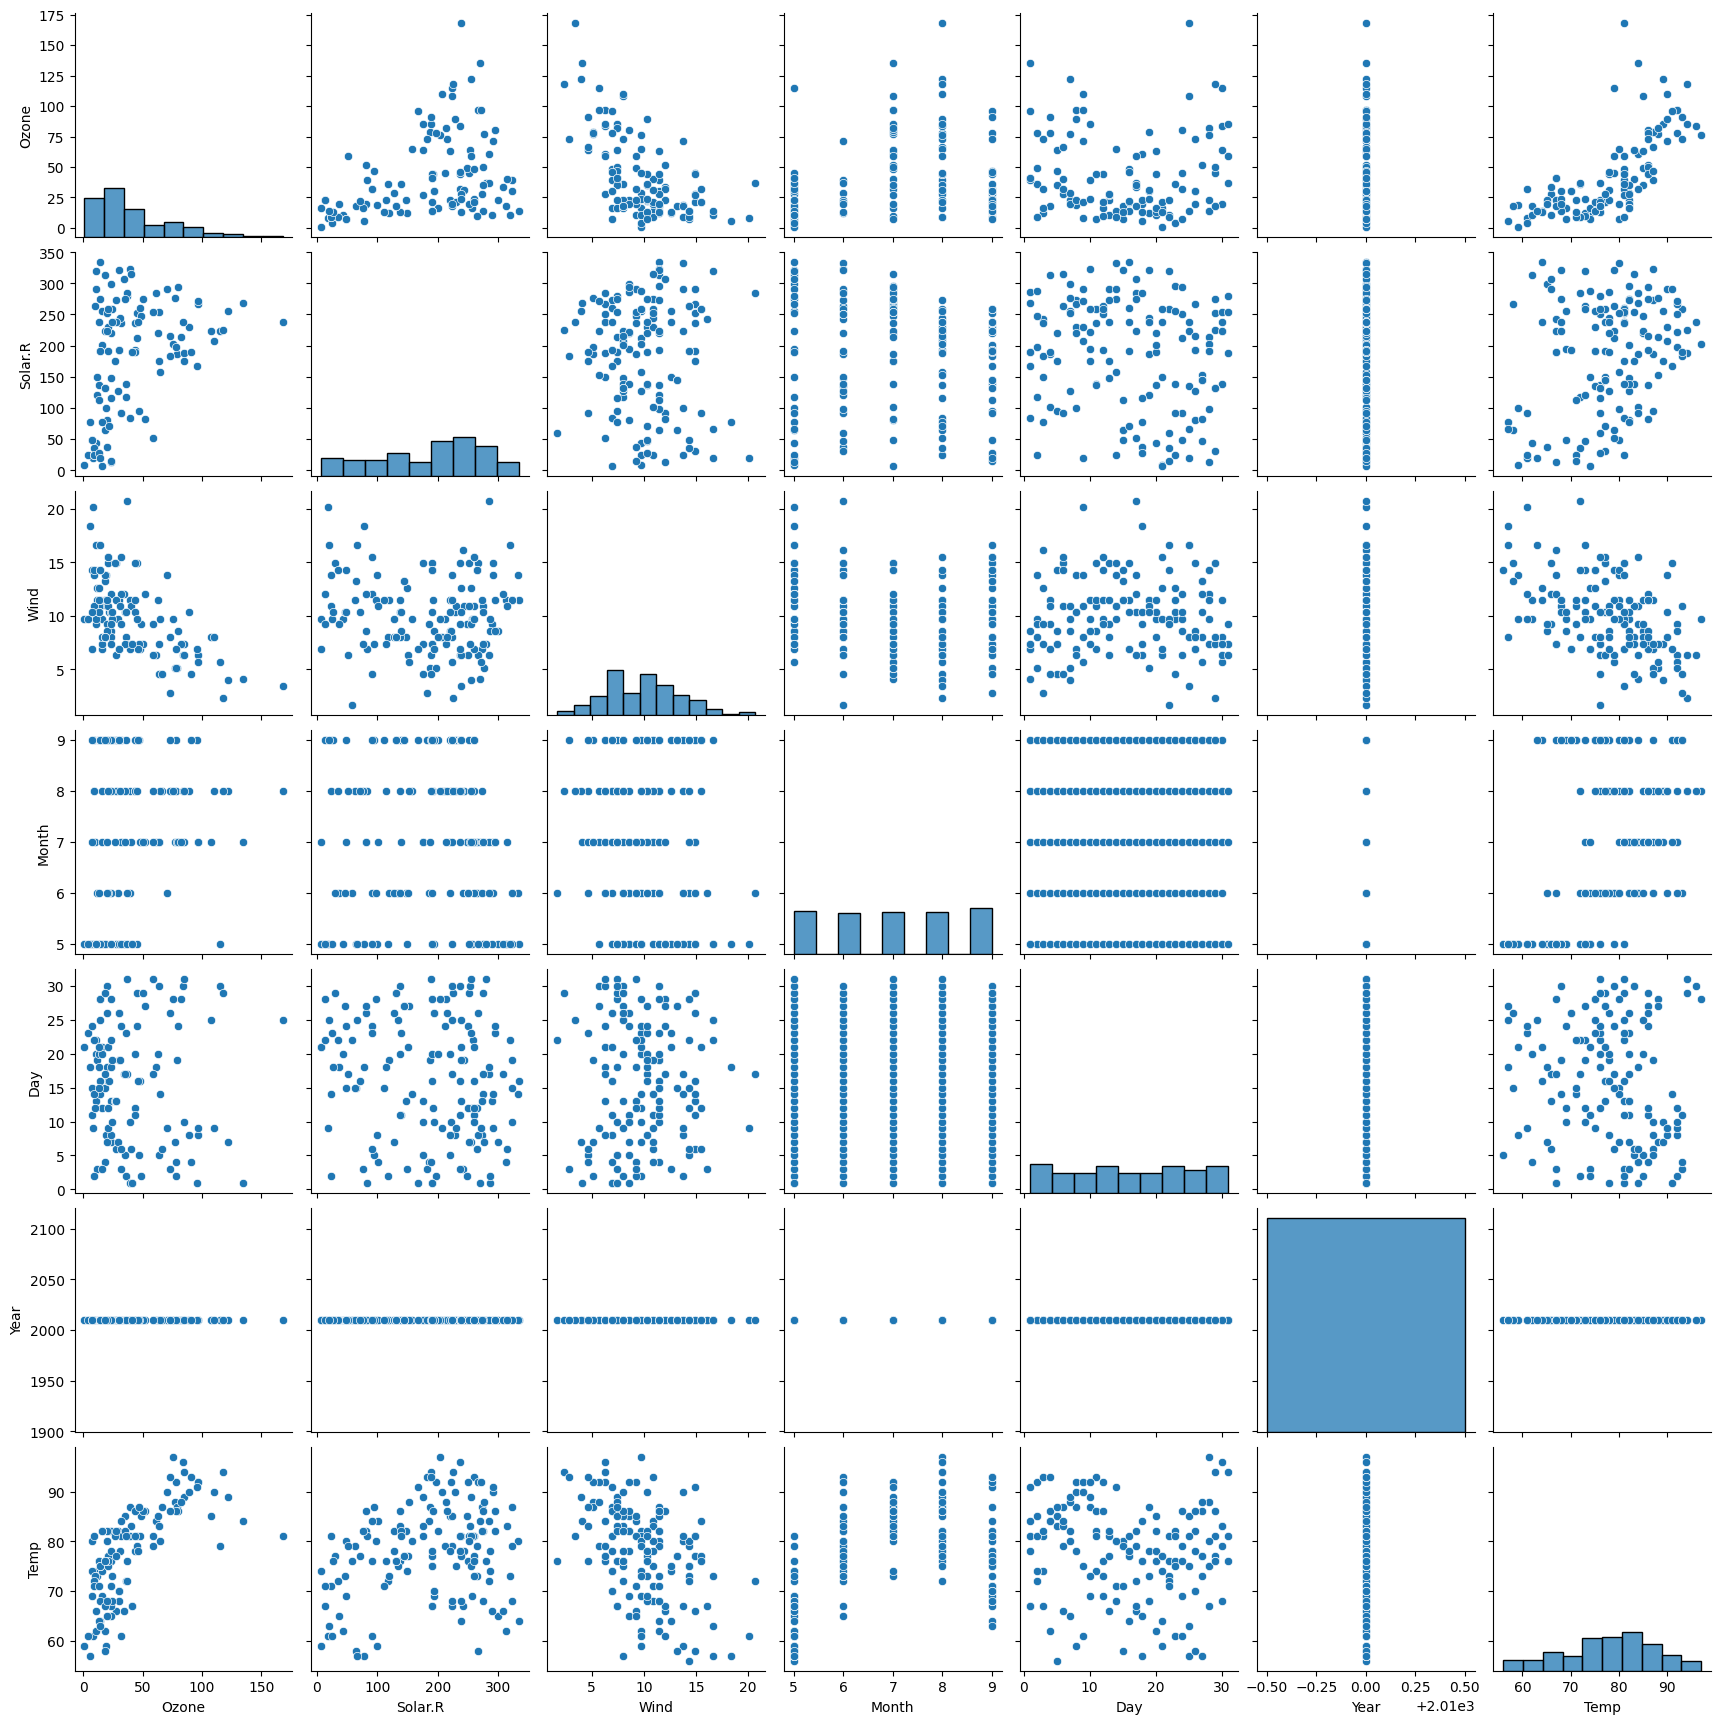

In [103]:
import seaborn as sns
pd.plotting.scatter_matrix(data)
sns.pairplot(data)

In [104]:
#correlation
data2.corr(numeric_only=True)

,Ozone,Solar,Wind,Month,Day,Year,Temp
Ozone,1.000000,0.304559,-0.520004,0.135096,-0.021916,NaN,0.606500
Solar,0.304559,1.000000,-0.055874,-0.080237,-0.151007,NaN,0.260677
Wind,-0.520004,-0.055874,1.000000,-0.170328,0.029900,NaN,-0.441228
Month,0.135096,-0.080237,-0.170328,1.000000,0.041438,NaN,0.408060
Day,-0.021916,-0.151007,0.029900,0.041438,1.000000,NaN,-0.122787
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temp,0.606500,0.260677,-0.441228,0.408060,-0.122787,NaN,1.000000


In [105]:
data2.head()

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
0,41.000000,190.000000,7.4,5.0,1,2010,67,S
1,36.000000,118.000000,8.0,5.0,2,2010,72,C
2,12.000000,149.000000,12.6,5.0,3,2010,74,PS
3,18.000000,313.000000,11.5,5.0,4,2010,62,S
4,41.815126,185.366667,14.3,5.0,5,2010,56,S


In [106]:
data3=pd.get_dummies(data2,columns=['Weather']).astype(int)

In [107]:
data3

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather_C,Weather_PS,Weather_S
0,41,190,7,5,1,2010,67,0,0,1
1,36,118,8,5,2,2010,72,1,0,0
2,12,149,12,5,3,2010,74,0,1,0
3,18,313,11,5,4,2010,62,0,0,1
4,41,185,14,5,5,2010,56,0,0,1
...,...,...,...,...,...,...,...,...,...,...
152,20,223,11,9,30,2010,68,0,0,1
153,41,190,7,5,1,2010,67,1,0,0
154,30,193,6,9,26,2010,70,0,1,0
155,41,145,13,9,27,2010,77,0,0,1


## Normalization

In [108]:
from numpy import set_printoptions
from sklearn.preprocessing import MinMaxScaler


In [109]:
array=data3.values
array

array([[ 41, 190,   7, ...,   0,   0,   1],
       [ 36, 118,   8, ...,   1,   0,   0],
       [ 12, 149,  12, ...,   0,   1,   0],
       ...,
       [ 30, 193,   6, ...,   0,   1,   0],
       [ 41, 145,  13, ...,   0,   0,   1],
       [ 18, 131,   8, ...,   1,   0,   0]], shape=(157, 10))

In [110]:
scaler=MinMaxScaler(feature_range=(0,1))
rescaledX=scaler.fit_transform(array)

In [111]:
#set_printoptions(precision=2)
print(rescaledX[0:5,:])

[[0.24 0.56 0.32 0.   0.   0.   0.27 0.   0.   1.  ]
 [0.21 0.34 0.37 0.   0.03 0.   0.39 1.   0.   0.  ]
 [0.07 0.43 0.58 0.   0.07 0.   0.44 0.   1.   0.  ]
 [0.1  0.94 0.53 0.   0.1  0.   0.15 0.   0.   1.  ]
 [0.24 0.54 0.68 0.   0.13 0.   0.   0.   0.   1.  ]]


## Standard Scalar

In [112]:
from numpy import set_printoptions
from sklearn.preprocessing import StandardScaler

In [113]:
array = data3.values
scaler = StandardScaler()
scaler.fit(array)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [114]:
rescaled2X = scaler.transform(array)

set_printoptions(precision=2)
print(rescaled2X[0:5, :])

[[-0.02  0.05 -0.71 -1.41 -1.67  0.   -1.15 -0.67 -0.65  1.25]
 [-0.2  -0.78 -0.42 -1.41 -1.56  0.   -0.61  1.48 -0.65 -0.8 ]
 [-1.05 -0.42  0.74 -1.41 -1.45  0.   -0.4  -0.67  1.53 -0.8 ]
 [-0.83  1.47  0.45 -1.41 -1.33  0.   -1.68 -0.67 -0.65  1.25]
 [-0.02 -0.    1.31 -1.41 -1.22  0.   -2.32 -0.67 -0.65  1.25]]
